In [1]:
!pip install torch

In [25]:
import os
import sys
import torch
import torchvision
from torchvision import transforms
import PIL
from PIL import Image
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import shutil


In [13]:
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("---")
print("pandas version:", pd.__version__)
print("PIL version:", PIL.__version__)
print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)

Platform: linux
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
---
pandas version: 2.2.2
PIL version: 11.3.0
torch version: 2.11.0+cpu
torchvision version: 0.26.0+cpu


In [14]:
zip_path = "/content/drive/MyDrive/wildlife.zip"
extraction_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [23]:
data_dir = os.path.join("dataset", "train_features")

classes = os.listdir(data_dir)
print(classes)

['ZJ008403.jpg', 'ZJ002577.jpg', 'ZJ001841.jpg', 'ZJ005579.jpg', 'ZJ005090.jpg', 'ZJ012729.jpg', 'ZJ008558.jpg', 'ZJ001527.jpg', 'ZJ013964.jpg', 'ZJ010174.jpg', 'ZJ015064.jpg', 'ZJ015150.jpg', 'ZJ015692.jpg', 'ZJ000908.jpg', 'ZJ004813.jpg', 'ZJ004687.jpg', 'ZJ004943.jpg', 'ZJ001861.jpg', 'ZJ013540.jpg', 'ZJ007899.jpg', 'ZJ010319.jpg', 'ZJ016216.jpg', 'ZJ007393.jpg', 'ZJ001895.jpg', 'ZJ005948.jpg', 'ZJ001552.jpg', 'ZJ002175.jpg', 'ZJ003332.jpg', 'ZJ009368.jpg', 'ZJ008099.jpg', 'ZJ013497.jpg', 'ZJ008515.jpg', 'ZJ000028.jpg', 'ZJ011330.jpg', 'ZJ000148.jpg', 'ZJ006893.jpg', 'ZJ015599.jpg', 'ZJ008361.jpg', 'ZJ015866.jpg', 'ZJ001195.jpg', 'ZJ000171.jpg', 'ZJ012430.jpg', 'ZJ011735.jpg', 'ZJ008774.jpg', 'ZJ009945.jpg', 'ZJ001547.jpg', 'ZJ012110.jpg', 'ZJ004435.jpg', 'ZJ009590.jpg', 'ZJ004844.jpg', 'ZJ006312.jpg', 'ZJ013971.jpg', 'ZJ009490.jpg', 'ZJ010374.jpg', 'ZJ010890.jpg', 'ZJ012523.jpg', 'ZJ007223.jpg', 'ZJ012678.jpg', 'ZJ005495.jpg', 'ZJ014547.jpg', 'ZJ003522.jpg', 'ZJ001344.jpg', 'ZJ0055

In [20]:
print(len(classes))

16489


In [22]:
df = pd.read_csv("dataset/train_labels.csv")
df.head()

,id,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent
0,ZJ000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ZJ000001,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,ZJ000002,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ZJ000003,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,ZJ000004,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [24]:
df.shape

(16488, 9)

# Creating Classes Subdirectories

In [26]:
source_dir = "dataset/train_features"

dest_dir = "dataset/organized_features"


classes = df.columns[1:]

for animal_class in classes:
    os.makedirs(os.path.join(dest_dir, animal_class), exist_ok=True)

animal_mapping = df.set_index('id').idxmax(axis=1)

print(f"Creating folders and sorting {len(animal_mapping)} images...")

# Iterate through the mapping and physically move the images
for img_id, animal_class in tqdm(animal_mapping.items(), total=len(animal_mapping)):

    src_path = os.path.join(source_dir, f"{img_id}.jpg")
    dst_path = os.path.join(dest_dir, animal_class, f"{img_id}.jpg")

    if os.path.exists(src_path):

        shutil.move(src_path, dst_path)

print(" Organized Classes Executed")

Creating folders and sorting 16488 images...


100%|██████████| 16488/16488 [00:00<00:00, 24059.52it/s]

 Organized Classes Executed


In [27]:
organized_data_dir = os.path.join("dataset", "organized_features")

classes = os.listdir(organized_data_dir)
print(classes)
print("=" * 50)
print(f"Total Number of Classes: {len(classes)}")

['blank', 'antelope_duiker', 'rodent', 'hog', 'bird', 'monkey_prosimian', 'civet_genet', 'leopard']
Total Number of Classes: 8


In [29]:
class_distribution_dict = {}

for sub_dir in classes:
    class_dir = os.path.join(organized_data_dir, sub_dir)
    num_images = len(os.listdir(class_dir))
    class_distribution_dict[sub_dir] = num_images

class_distributions = pd.Series(class_distribution_dict)
print(class_distributions)

blank               2213
antelope_duiker     2474
rodent              2013
hog                  978
bird                1641
monkey_prosimian    2492
civet_genet         2423
leopard             2254
dtype: int64


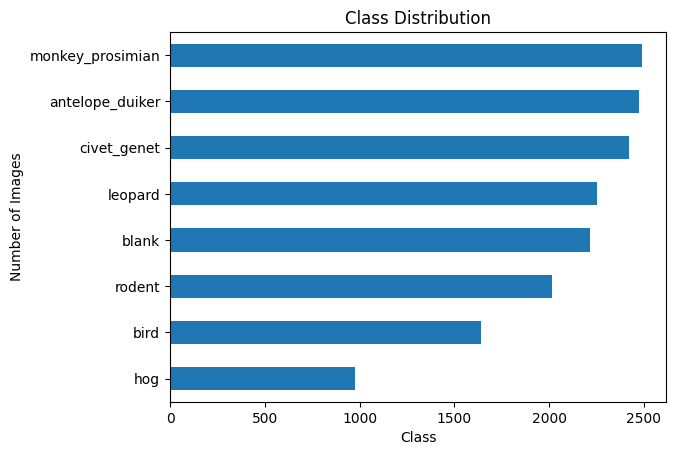

In [31]:
class_distributions.sort_values().plot(kind='barh', title='Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.show()

# Image Exploration

In [41]:
monkey_image_path = os.path.join("dataset","organized_features")
monkey_image_path_2 = os.path.join(monkey_image_path, "monkey_prosimian")

monkey_images = os.listdir(monkey_image_path_2)

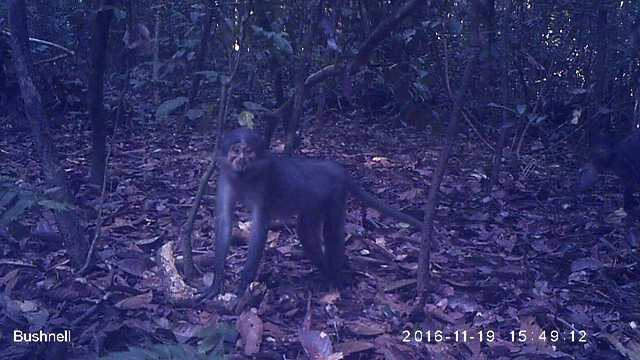

In [42]:
monkey_image_example  = os.path.join(monkey_image_path_2, monkey_images[0])
monkey_image_pil = Image.open(monkey_image_example)
monkey_image_pil

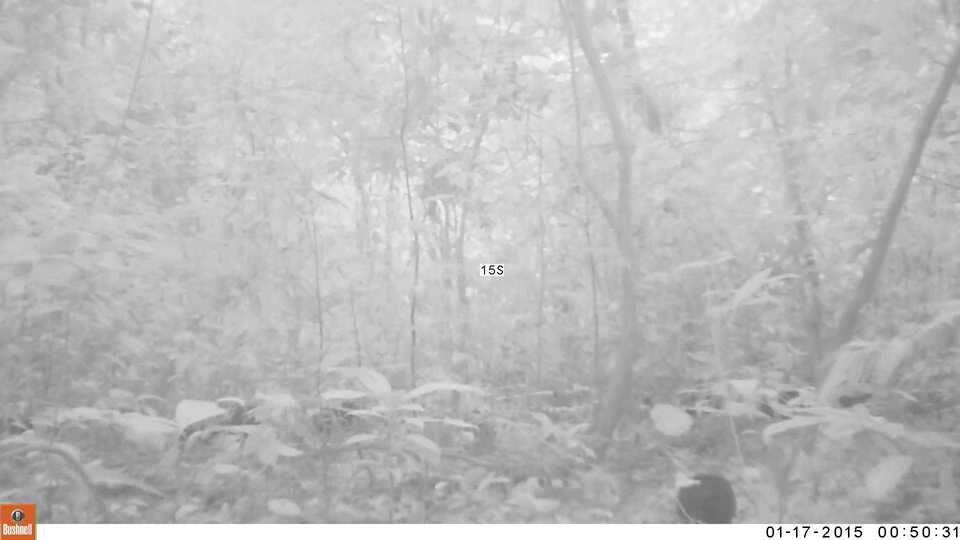

In [48]:
bird_image_path = os.path.join(monkey_image_path, "bird")
bird_images = os.listdir(bird_image_path)

bird_image_example = os.path.join(bird_image_path, bird_images[0])
bird_image_pil = Image.open(bird_image_example)

bird_image_pil

# Image Properties

In [49]:
print(monkey_image_pil.size)
print(monkey_image_pil.mode)
print(bird_image_pil.size)
print(bird_image_pil.mode)

(640, 360)
RGB
(960, 540)
RGB


# Conversion Into Tensors

In [50]:
monkey_tensor = transforms.ToTensor()(monkey_image_pil)
bird_tensor = transforms.ToTensor()(bird_image_pil)

In [53]:
print("monkey tensor shape",monkey_tensor.shape)
print("=" * 50)
print("bird tensor shape",bird_tensor.shape)
print("=" * 50)
print("monkey tensor dtype",monkey_tensor.dtype)
print("=" * 50)
print("bird tensor dtype",bird_tensor.dtype)
print("=" * 50)
print("monkey tensor device",monkey_tensor.device)
print("=" * 50)
print("bird tensor device",bird_tensor.device)

monkey tensor shape torch.Size([3, 360, 640])
bird tensor shape torch.Size([3, 540, 960])
monkey tensor dtype torch.float32
bird tensor dtype torch.float32
monkey tensor device cpu
bird tensor device cpu


In [54]:
channel,height,width = bird_tensor.shape

print(f"Channel: {channel}")
print(f"Height: {height}")
print(f"Width: {width}")

Channel: 3
Height: 540
Width: 960


In [55]:
bird_tensor

tensor([[[0.6941, 0.6941, 0.7020,  ..., 0.6706, 0.6510, 0.6353],
         [0.6863, 0.6902, 0.6980,  ..., 0.6627, 0.6471, 0.6353],
         [0.6745, 0.6784, 0.6941,  ..., 0.6588, 0.6431, 0.6353],
         ...,
         [0.9647, 0.8392, 0.7608,  ..., 0.7686, 0.9451, 1.0000],
         [0.9725, 0.8510, 0.7725,  ..., 1.0000, 0.9451, 1.0000],
         [0.9765, 0.8588, 0.7765,  ..., 1.0000, 0.9647, 1.0000]],

        [[0.6941, 0.6941, 0.7020,  ..., 0.6706, 0.6510, 0.6353],
         [0.6863, 0.6902, 0.6980,  ..., 0.6627, 0.6471, 0.6353],
         [0.6745, 0.6784, 0.6941,  ..., 0.6588, 0.6431, 0.6353],
         ...,
         [0.5843, 0.4588, 0.3686,  ..., 0.7686, 0.9451, 1.0000],
         [0.5804, 0.4549, 0.3647,  ..., 1.0000, 0.9451, 1.0000],
         [0.5804, 0.4510, 0.3647,  ..., 1.0000, 0.9647, 1.0000]],

        [[0.6941, 0.6941, 0.7020,  ..., 0.6706, 0.6510, 0.6353],
         [0.6863, 0.6902, 0.6980,  ..., 0.6627, 0.6471, 0.6353],
         [0.6745, 0.6784, 0.6941,  ..., 0.6588, 0.6431, 0.

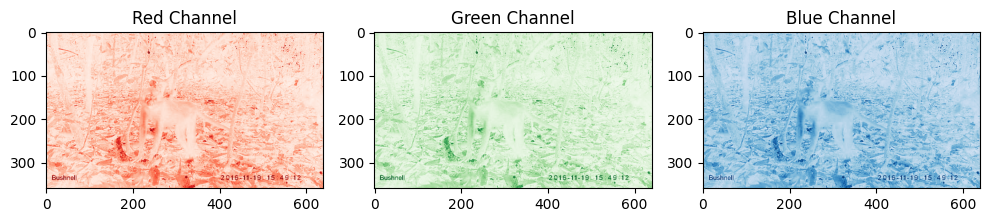

In [62]:
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(10, 5))

# Red Channel of shark tensor
ax0.imshow(monkey_tensor[0], cmap='Reds')
ax0.set_title('Red Channel')

# Green Channel of shark tensor
ax1.imshow(monkey_tensor[1], cmap='Greens')
ax1.set_title('Green Channel')

# Blue Channel of shark tensor
ax2.imshow(monkey_tensor[2], cmap='Blues')
ax2.set_title('Blue Channel')

plt.tight_layout()
plt.show()


